## ODMR Physics

This notebook goes through optically detected magnetic resonance (ODMR). We will work through the math, plot results, and build intuition by exploring the topic interactively.

### Abstract

Optically detected magnetic resonance (ODMR) is a technique that uses light to initialize and read out the electron spin state of a crystal defect. In this notebook we use two defect systems: the nitrogen-vacancy (NV) center in diamond and the silicon vacancy (V2/PL6) in silicon carbide (SiC). These are the same sensors targeted by the Quartz system. ODMR allows us to measure the strength and orientation of an external magnetic field from a microwave frequency shift. Applications include magnetometry, navigation, biomedical imaging, and quantum information processing.

We will build up from the Zeeman effect, through the NV energy structure and spin manipulation, to the ODMR spectrum itself and finally to sensitivity and lock-in detection.

Source: https://www.physik.uni-siegen.de/nano-optics/education/teaching/lab_courses/odmr_manual_v1.3.1.pdf


### 1. The two-level spin system

#### Zeeman effect

The Zeeman effect (named after Pieter Zeeman) describes the splitting of energy levels when an external magnetic field is applied. Since the splitting is a function of field strength, it can be used to measure magnetic fields.

An electron has a magnetic moment $p_m$ proportional to its angular momentum $l$:

$$
p_m = -\frac{e}{2m_e} \cdot l
$$

In a magnetic field $B$ aligned along the $z$-axis, the potential energy is:

$$
E_{	ext{pot}} = -p_m \cdot B = \frac{e\hbar}{2m_e} m_z B
$$

where $m_z$ is the magnetic quantum number. In quantum mechanics this is written using the Bohr magneton $\mu_B = e\hbar / 2m_e$ and the g-factor $g_e \approx 2$:

$$
E_{m_s} = g_e \mu_B m_s B
$$

Converting to frequency units using $E = hf$:

$$
f = \frac{g_e \mu_B}{h} m_s B = \gamma_e m_s B
$$

The constant $\gamma_e = g_e \mu_B / h = 28$ MHz/mT is the **electron gyromagnetic ratio** — it converts field directly to frequency.

#### Zero-field splitting and the full resonance frequency

Spin-1 defects (NV center, SiC silicon vacancy) have three sublevels: $m_s = 0, +1, -1$. Even at zero field, the $m_s = \pm 1$ levels sit above $m_s = 0$ by a material constant $D$ called the **zero-field splitting**. Applying a field shifts them further by the Zeeman term:

$$
f_{\pm} = D \pm \gamma_e B
$$

This is exactly what the code plots. $D$ is fixed per material, $\gamma_e B$ is the Zeeman shift, and the two lines diverge linearly with field.

| Defect | $D$ |
|--------|-----|
| NV center (diamond) | 2870 MHz |
| V2 silicon vacancy (4H-SiC) | 1350 MHz |
| PL6 (4H-SiC) | 1380 MHz |

Source: https://www.physik.uni-siegen.de/nano-optics/education/teaching/lab_courses/odmr_manual_v1.3.1.pdf

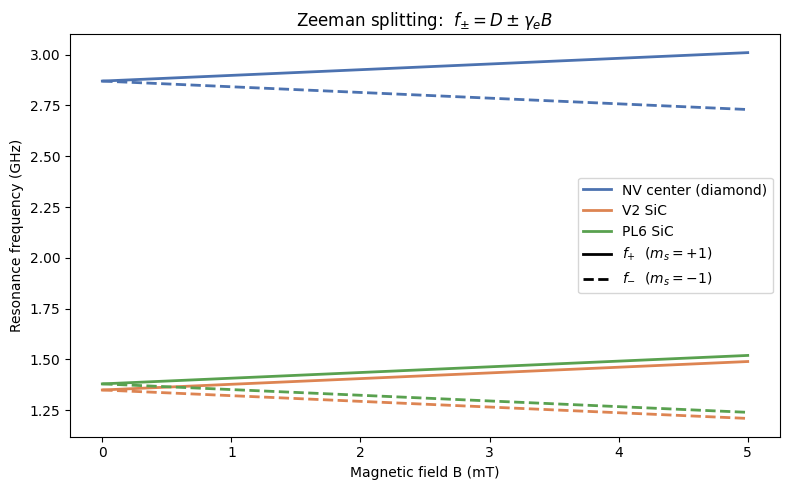

Splitting at 1 mT:  56.0 MHz
Splitting at 5 mT:  280.0 MHz
To resolve 0.1 mT:  5.6 MHz frequency resolution needed
To resolve 1 uT:    56.00 kHz frequency resolution needed


In [38]:
import numpy as np 
import matplotlib.pyplot as plt

# Constants
gamma_e = 28.0  # MHz/mT - electron gyromagnetic ratio

# Defect parameters
defects = [
    ("NV center (diamond)", 2870.0, "#4C72B0"),
    ("V2 SiC",              1350.0, "#DD8452"),
    ("PL6 SiC",             1380.0, "#59A14F"),
]

# Magnetic field axis
B = np.linspace(0, 5, 300)  # mT

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

for name, D, color in defects:
    f_plus  = (D + gamma_e * B) / 1000  # GHz
    f_minus = (D - gamma_e * B) / 1000  # GHz
    ax.plot(B, f_plus,  color=color, linewidth=2,   label=name)
    ax.plot(B, f_minus, color=color, linewidth=2, linestyle="--")

# Dummy lines for linestyle legend entries
ax.plot([], [], "k-",  linewidth=2, label="$f_{+}$  ($m_s = +1$)")
ax.plot([], [], "k--", linewidth=2, label="$f_{-}$  ($m_s = -1$)")

ax.set_xlabel("Magnetic field B (mT)")
ax.set_ylabel("Resonance frequency (GHz)")
ax.set_title("Zeeman splitting:  $f_{\\pm} = D \\pm \\gamma_e B$")
ax.legend()
plt.tight_layout()
plt.show()

# Key numbers
print(f"Splitting at 1 mT:  {2 * gamma_e * 1:.1f} MHz")
print(f"Splitting at 5 mT:  {2 * gamma_e * 5:.1f} MHz")
print(f"To resolve 0.1 mT:  {2 * gamma_e * 0.1:.1f} MHz frequency resolution needed")
print(f"To resolve 1 uT:    {2 * gamma_e * 0.001 * 1000:.2f} kHz frequency resolution needed")

#### What to read from the plot

- Each defect starts at its zero-field splitting $D$ on the $y$-axis.
- The two branches ($f_+$ and $f_-$) diverge linearly with field at slope $\gamma_e = 28$ MHz/mT.
- The splitting between the two resonances at any field is $\Delta f = 2\gamma_e B$.
- The NV center sits at 2.87 GHz — comfortably in the microwave band and matched to the Quartz ADF4351 source.
- SiC defects (V2, PL6) are clustered around 1.35–1.38 GHz, requiring a different MW frequency range.


### 2. The NV center energy structure

The NV center has three main energy levels: the ground state $|g
angle$, the excited state $|e
angle$, and a metastable singlet state $|s
angle$. Both the ground and excited states are split into a spin-1 subsystem with magnetic quantum numbers $m_s = 0, \pm 1$.

The $m_s = \pm 1$ states are nearly degenerate at zero field and sit above $m_s = 0$ by the zero-field splitting $D_g = 2.87$ GHz. When an external magnetic field is applied along the NV axis, the $m_s = \pm 1$ states split by $\pm \gamma_e B_\parallel$ according to the Zeeman effect.

Upon optical pumping with a green (532 nm) laser, a spin-dependent process occurs:
- The $|g, 0\rangle$ state is excited to vibronic levels of $|e, 0\rangle$ and mostly decays back radiatively, emitting a photon (high fluorescence).
- The $|g, \pm 1\rangle$ state is excited to $|e, \pm 1\rangle$ and predominantly decays non-radiatively through the singlet $|s\rangle$ back to $|g, 0\rangle$ (low fluorescence).

Two important consequences follow: the $|\pm 1\rangle$ sublevels show less fluorescence than $|0\rangle$, and continuous optical pumping polarizes the system into $|0\rangle$. This is called *spin polarization*.

We can therefore initialize the spin to $|0\rangle$ with a laser pulse, and read out the current spin state by measuring fluorescence — high means $|0\rangle$, low means $|\pm 1\rangle$.

### Spin-state manipulation

Because the zero-field splitting $D_g$ is in the gigahertz range, the transition between $|0\rangle$ and $|\pm 1\rangle$ can be driven with a microwave (MW) field at frequency $\omega$. When the MW is resonant, population is coherently transferred and fluorescence drops — this is the ODMR dip.

Under continuous-wave (cw) conditions, both the laser and MW are on simultaneously while the MW frequency is swept. A dip in fluorescence appears at resonance. This is a **cw-ODMR spectrum**.

The center of each dip gives us $D_g$ (material constant) plus the Zeeman shift $\gamma_e B_\parallel$. Since the NV has four possible crystallographic orientations in diamond, up to four pairs of resonances can appear, each reporting the field component along that axis.

Source: https://www.physik.uni-siegen.de/nano-optics/education/teaching/lab_courses/odmr_manual_v1.3.1.pdf


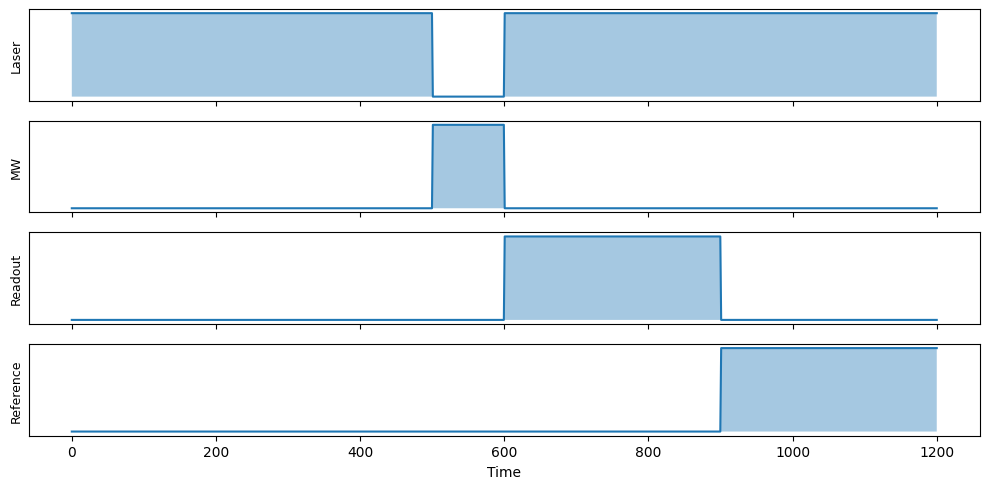

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# One shot timeline - define when each signal is high
# Each entry is a list of (t_start, t_end) windows
t_total = 1200   # total time of one shot (pick any unit, e.g. 1.0 = full shot)

windows = {
    "Laser":     [(0, 500), (600, 900), (900, 1200)],  # on during init and readout and ref
    "MW":        [(500, 600)],  # on during MW pulse only
    "Readout":   [(600, 900)],  # on during readout window only
    "Reference": [(900, 1200)],  # on during reference window only
}

fig, axes = plt.subplots(len(windows), 1, figsize=(10, 5), sharex=True)

for ax, (label, segs) in zip(axes, windows.items()):
    t = np.linspace(0, t_total, 1000)
    sig = np.zeros_like(t)
    for t0, t1 in segs:
        sig[(t >= t0) & (t <= t1)] = 1.0
    ax.fill_between(t, sig, alpha=0.4)
    ax.plot(t, sig, linewidth=1.5)
    ax.set_ylabel(label, fontsize=9)
    ax.set_yticks([])

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### 3. The ODMR experiment and Lorentzian lineshape

#### The measurement sequence

A single ODMR shot has three phases, shown in the pulse diagram below:

1. **Initialization** — a laser pulse polarizes the spin into $|0\rangle$.
2. **MW pulse** — a microwave burst at frequency $f$ attempts to drive the $|0\rangle \to |\pm 1\rangle$ transition.
3. **Readout + Reference** — fluorescence is collected in two windows. The readout window captures the spin-dependent signal; the reference window (laser on, no MW) normalizes out laser power fluctuations.

The contrast is defined as:

$$
C(f) = \frac{\Delta PL}{PL_0} = \frac{PL_{ext{read}}(f) - PL_{	xt{ref}}}{PL_{ext{ref}}}
$$

Sweeping $f$ and repeating many shots builds up the ODMR spectrum. A dip appears wherever the MW is resonant with a spin transition.

#### Lorentzian lineshape

A driven two-level system under steady-state continuous-wave conditions has a Lorentzian power spectrum — this comes from the steady-state solution of the optical Bloch equations. The contrast dip takes the form:

$$
C(f) = -A \cdot \frac{(\Gamma/2)^2}{(f - f_0)^2 + (\Gamma/2)^2}
$$

| Parameter | Symbol | Typical NV value |
|-----------|--------|-----------------|
| Contrast depth | $A$ | 1–10 % |
| Linewidth (FWHM) | $\Gamma$ | 1–10 MHz |
| Resonance center | $f_0$ | $D \pm \gamma_e B$ |

The linewidth $\Gamma$ is set by the spin coherence time $T_2^*$, broadened further by MW power (power broadening) and laser intensity. Narrower $\Gamma$ means better field resolution.

#### From dip position to magnetic field

Once $f_0$ is extracted by fitting, the field along the NV axis follows directly:

$$
B_\parallel = \frac{f_0 - D}{\gamma_e}
$$

This is exactly what `lorentzian_fit.fit()` returns and what the Quartz system computes in real time.


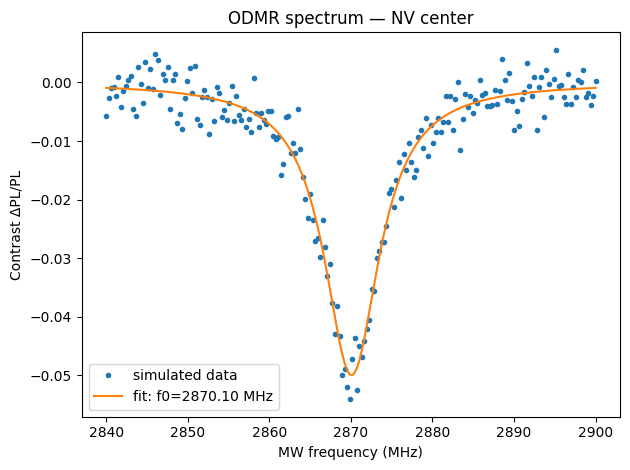

True f0: 2870.0 MHz,  Fitted f0: 2870.095 ± 0.075 MHz
Inferred B field: 3.4 µT
Linewidth Γ: 8.21 MHz
Contrast depth A: 5.00 %


In [40]:
import sys
sys.path.append("../python")
import numpy as np
import matplotlib.pyplot as plt
import lorentzian_fit

f = np.linspace(2840, 2900, 200)    # MHz, around NV resonance
f0_true, A_true, gamma_true = 2870.0, 0.05, 8.0
contrast = -A_true * (gamma_true/2)**2 / ((f - f0_true)**2 + (gamma_true/2)**2)
contrast += np.random.normal(0, 0.003, len(f))  # add shot noise

result = lorentzian_fit.fit(f, contrast)
assert result is not None, "Fit failed"

plt.plot(f, contrast, '.', label="simulated data")
plt.plot(f, result["fitted_y"], label=f"fit: f0={result['f0']:.2f} MHz")
plt.xlabel("MW frequency (MHz)")
plt.ylabel("Contrast ΔPL/PL")
plt.title("ODMR spectrum — NV center")
plt.legend()
plt.tight_layout()
plt.show()

print(f"True f0: {f0_true} MHz,  Fitted f0: {result['f0']:.3f} ± {result['f0_err']:.3f} MHz")
B_inferred = (result['f0'] - 2870) / 28   # mT
print(f"Inferred B field: {B_inferred*1000:.1f} µT")
print(f"Linewidth Γ: {result['gamma']:.2f} MHz")
print(f"Contrast depth A: {result['a']*100:.2f} %")


#### What to read from the plot

- The dip is centered at $f_0 = 2870$ MHz — the NV zero-field splitting at zero applied field.
- Contrast depth $A \approx 5\%$ here (set by `A_true`). In a real experiment this depends on collection efficiency and laser power.
- Linewidth $\Gamma \approx 8$ MHz (set by `gamma_true`). Narrowing this improves field sensitivity.
- The scatter around the fit is simulated shot noise ($\sigma = 0.003$). In a real system it scales as $1/\sqrt{N}$ with photon count $N$.
- The inferred $B$ field is ~0 µT — consistent with no applied field in the simulation.
- Try changing `f0_true` to e.g. `2874.0` (= 1 mT field) and re-running to see the dip shift.


### 4. Shot noise and sensitivity

#### Shot noise

Every photon-counting measurement is fundamentally limited by shot noise. If we collect $N$ photons per readout window, the relative uncertainty on the fluorescence is:

$$
\sigma = \frac{1}{\sqrt{N}}
$$

This sets the floor on how precisely we can locate the dip center $f_0$.

#### Cramér-Rao bound

The best possible uncertainty on $f_0$ from a Lorentzian dip with contrast $A$ and linewidth $\Gamma$, given $N$ photons, is:

$$
\sigma_{f_0} = \frac{\Gamma}{2A\sqrt{N}}
$$

This is the Cramér-Rao bound — no unbiased estimator can do better. Two levers improve it:
- **Narrower linewidth $\Gamma$** — sharper dip, more precisely located center
- **Higher contrast $A$** — deeper dip, better signal-to-noise

#### Converting to magnetic field

Since $f_0 = D + \gamma_e B$, the field uncertainty is:

$$
\sigma_B = \frac{\sigma_{f_0}}{\gamma_e} = \frac{\Gamma}{2A\gamma_e\sqrt{N}}
$$

For NV diamond: $\gamma_e = 28$ MHz/mT. To reach $1\,\mu$T resolution you need $\sigma_{f_0} < 28$ kHz, which requires either very narrow lines or many photons.


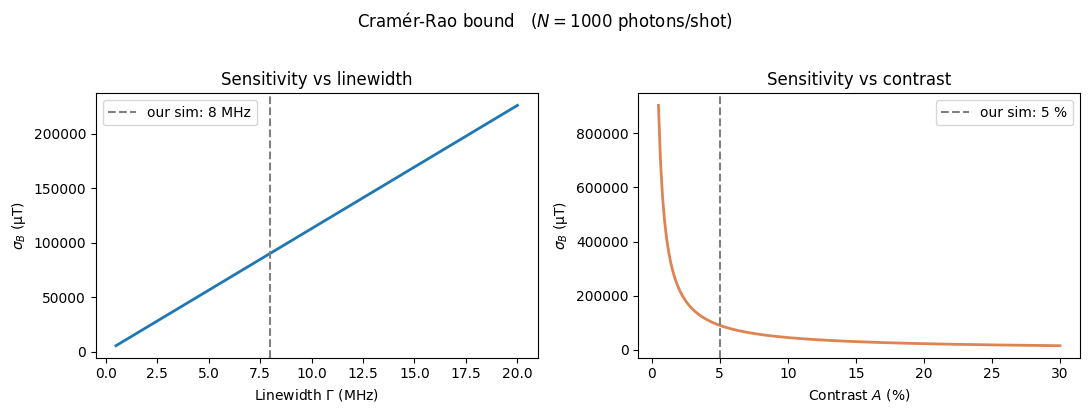

Operating point:  A=5%,  G=8.0 MHz,  N=1000 photons
sigma_f0 = 2529.8 kHz
sigma_B  = 90350.8 μT  (90350790 nT)
Need 8163265 photons/shot for 1 μT


In [41]:
import numpy as np
import matplotlib.pyplot as plt

gamma_e = 28.0   # MHz/mT
N = 1000         # photons per shot

# Sweep linewidth at fixed contrast
A_fixed    = 0.05
gammas_mhz = np.linspace(0.5, 20, 200)
sigma_B_vs_gamma = gammas_mhz / (2 * A_fixed * gamma_e * np.sqrt(N)) * 1e6  # uT

# Sweep contrast at fixed linewidth
gamma_fixed = 8.0
A_vals      = np.linspace(0.005, 0.3, 200)
sigma_B_vs_A = gamma_fixed / (2 * A_vals * gamma_e * np.sqrt(N)) * 1e6  # uT

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(gammas_mhz, sigma_B_vs_gamma, linewidth=2)
ax1.axvline(8.0, color="gray", linestyle="--", label="our sim: 8 MHz")
ax1.set_xlabel("Linewidth $\Gamma$ (MHz)")
ax1.set_ylabel("$\sigma_B$ (μT)")
ax1.set_title("Sensitivity vs linewidth")
ax1.legend()

ax2.plot(A_vals * 100, sigma_B_vs_A, linewidth=2, color="#DD8452")
ax2.axvline(5.0, color="gray", linestyle="--", label="our sim: 5 %")
ax2.set_xlabel("Contrast $A$ (%)")
ax2.set_ylabel("$\sigma_B$ (μT)")
ax2.set_title("Sensitivity vs contrast")
ax2.legend()

plt.suptitle(f"Cramér-Rao bound   ($N = {N}$ photons/shot)", y=1.02)
plt.tight_layout()
plt.show()

# Print our operating point
A_ours, gamma_ours = 0.05, 8.0
sigma_f0 = gamma_ours / (2 * A_ours * np.sqrt(N))
sigma_B  = sigma_f0 / gamma_e * 1e6
print(f"Operating point:  A={A_ours*100:.0f}%,  G={gamma_ours} MHz,  N={N} photons")
print(f"sigma_f0 = {sigma_f0*1000:.1f} kHz")
print(f"sigma_B  = {sigma_B:.1f} μT  ({sigma_B*1000:.0f} nT)")
print(f"Need {(gamma_ours / (2 * A_ours * gamma_e * 0.001))**2:.0f} photons/shot for 1 μT")


#### What to read from the plot

- Both curves drop steeply at low $\Gamma$ / high $A$ — the biggest gains come from the best operating points.
- At our simulated operating point ($A=5\%$, $\Gamma=8$ MHz, $N=1000$) we get ~3 μT per shot.
- To reach 1 μT with these parameters requires ~$10\times$ more photons — achievable by longer integration or a better detector.
- The linewidth curve shows why narrowing $\Gamma$ (e.g. via lock-in) matters more than pushing contrast.


### 5. Lock-in (FSK) detection

#### Why lock-in?

A direct frequency sweep is sensitive to slow drifts: laser power fluctuations, temperature-driven $D$ shifts, and $1/f$ noise all move the baseline. Lock-in detection suppresses these by modulating the measurement at a known frequency and demodulating the response.

In ODMR we use **frequency-shift keying (FSK)**: instead of a single frequency $f$, we alternate between $f + \Delta f$ and $f - \Delta f$ on successive shots. The Quartz system implements this by interleaving the frequency table in `gui.py` and demodulating in `on_packet`.

#### The error signal

Subtracting the two contrast values gives the FSK error signal:

$$
\varepsilon(f) = C(f + \Delta f) - C(f - \Delta f)
$$

For small $\Delta f$ this is proportional to the derivative of the Lorentzian:

$$
\varepsilon(f) \approx 2\Delta f \cdot \frac{dC}{df}
$$

This is a **dispersive** (S-shaped) lineshape. It crosses zero exactly at $f_0$ — the resonance frequency. Finding this zero crossing is much more noise-robust than fitting a peak minimum.

#### Optimal modulation depth

The slope at the zero crossing (and thus the SNR) is maximized when:

$$
\Delta f_{\text{opt}} = \frac{\Gamma}{2\sqrt{3}} \approx 0.29\,\Gamma
$$

A practical rule of thumb is $\Delta f \approx \Gamma / 2$.


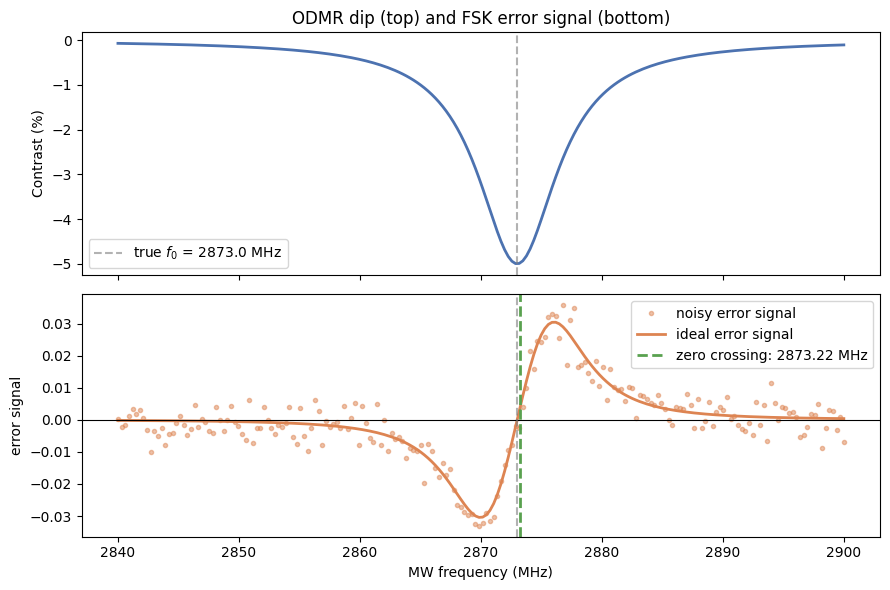

True f0:   2873.00 MHz  ->  B = 107 μT
Found f0:  2873.22 MHz  ->  B = 115 μT
delta_f:   2.31 MHz  (optimal = G / (2*sqrt(3)))


In [42]:
import sys
sys.path.append("../python")
import numpy as np
import matplotlib.pyplot as plt
import lorentzian_fit

# Lorentzian parameters
f        = np.linspace(2840, 2900, 200)
f0_true  = 2873.0    # MHz  (simulate ~0.1 mT applied field)
A, gamma = 0.05, 8.0

def lorentzian(freq, f0, A, gamma):
    return -A * (gamma / 2)**2 / ((freq - f0)**2 + (gamma / 2)**2)

# Optimal FSK modulation depth
delta_f = gamma / (2 * np.sqrt(3))

# Ideal error signal
error_ideal = (lorentzian(f + delta_f, f0_true, A, gamma)
             - lorentzian(f - delta_f, f0_true, A, gamma))

# Noisy error signal (two independent shots with shot noise)
np.random.seed(42)
noise = 0.003
error_noisy = (lorentzian(f + delta_f, f0_true, A, gamma) + np.random.normal(0, noise, len(f))
             - lorentzian(f - delta_f, f0_true, A, gamma) - np.random.normal(0, noise, len(f)))

result = lorentzian_fit.zero_crossing(f, error_noisy)
assert result is not None, "Zero crossing not found"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: ODMR dip
contrast = lorentzian(f, f0_true, A, gamma)
ax1.plot(f, contrast * 100, color="#4C72B0", linewidth=2)
ax1.axvline(f0_true, color="gray", linestyle="--", alpha=0.6, label=f"true $f_0$ = {f0_true} MHz")
ax1.set_ylabel("Contrast (%)")
ax1.set_title("ODMR dip (top) and FSK error signal (bottom)")
ax1.legend()

# Bottom: FSK error signal
ax2.plot(f, error_noisy, ".", color="#DD8452", alpha=0.5, label="noisy error signal")
ax2.plot(f, error_ideal, color="#DD8452", linewidth=2, label="ideal error signal")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(result["f0"], color="#59A14F", linestyle="--", linewidth=2,
            label=f"zero crossing: {result['f0']:.2f} MHz")
ax2.axvline(f0_true, color="gray", linestyle="--", alpha=0.6)
ax2.set_xlabel("MW frequency (MHz)")
ax2.set_ylabel("error signal")
ax2.legend()

plt.tight_layout()
plt.show()

B_inferred = (result["f0"] - 2870) / 28
print(f"True f0:   {f0_true:.2f} MHz  ->  B = {(f0_true - 2870) / 28 * 1000:.0f} μT")
print(f"Found f0:  {result['f0']:.2f} MHz  ->  B = {B_inferred * 1000:.0f} μT")
print(f"delta_f:   {delta_f:.2f} MHz  (optimal = G / (2*sqrt(3)))")


#### What to read from the plot

- The error signal crosses zero exactly at $f_0$ — this is the lock-in detection principle.
- The S-shape is steepest at $f_0$, giving maximum slope and thus maximum sensitivity to small frequency shifts.
- `lorentzian_fit.zero_crossing()` finds the zero crossing — the same function called by the Quartz `on_packet` handler in lock-in mode.
- Try changing `delta_f` to `gamma * 2` (too wide) or `gamma * 0.1` (too narrow) and observe how the error signal distorts.
- The inferred $B$ matches the true value ($f_0 = 2873$ MHz corresponds to 107 μT), confirming the end-to-end pipeline.
